## Dataset: Global Video Game Sales

**Source:** [Kaggle - Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogamesales)

### Project Overview
In this project, I analyze the Global Video Game Sales dataset to understand trends in the gaming industry. The analysis covers data cleaning, descriptive statistics, visualization, correlation analysis, and probability distribution testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10,6)

print("Libraries imported successfully")

Libraries imported successfully


## Data Preparation & Exploration

In [2]:
try:
    df = pd.read_csv('dataset.csv')
    print("Dataset loaded successfully\n")
except FileNotFoundError:
    print("Error 404: 'dataset.csv' not found")

print ("Dataset dimensions:")
print(f"Rows: {df.shape[0]}, \nColumns: {df.shape[1]}\n")

print ("First 5 rows:")
display(df.head())

print ("\nData types, missing values:")
df.info()


Dataset loaded successfully

Dataset dimensions:
Rows: 16598, 
Columns: 11

First 5 rows:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



Data types, missing values:
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [3]:
# Data cleaning

duplicates = df.duplicated().sum()
print (f"Number of duplicated rows: {duplicates}\n")

print ("Missing values before cleaning:\n",df.isnull().sum())

Number of duplicated rows: 0

Missing values before cleaning:
 Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


#### Because  year and publisher columns are crucial for analysis I decided to drop rows with missing values in these columns, I can do it because this missing values is small percentage of the whole data (like 1%)

In [4]:
df_clean = df.dropna(subset=['Year','Publisher']).copy()

df_clean['Year'] = df_clean['Year'].astype(int)

print ("Data info after cleaning:")
df_clean.info()

Data info after cleaning:
<class 'pandas.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  str    
 2   Platform      16291 non-null  str    
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  str    
 5   Publisher     16291 non-null  str    
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB


## Descriptive Statistics
Here we calculate central tendency (mean, median, mode), measures of dispersion (variance, standard deviation, range, IQR); identify data types and analyze them; create summary tables showing descriptive statistics grouped by categorical variables; identify and discuss any outliers


In [5]:
# Measures of central tendency for key numerical variables (sales)
numerical_cols = ['NA_Sales','EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

print ("Mean, media, mode:\n")
for col in numerical_cols:
    print(f"Variable: {col}")
    print(f"Mean: {df_clean[col].mean()}")
    print(f"Median: {df_clean[col].median()}")
    # Mode can be multiple, s0 we take the first one
    print(f"Mode: {df_clean[col].mode()[0]}")
    print()

Mean, media, mode:

Variable: NA_Sales
Mean: 0.26564667607881653
Median: 0.08
Mode: 0.0

Variable: EU_Sales
Mean: 0.14773126266036463
Median: 0.02
Mode: 0.0

Variable: JP_Sales
Mean: 0.07883309802958689
Median: 0.0
Mode: 0.0

Variable: Other_Sales
Mean: 0.048426124854213985
Median: 0.01
Mode: 0.0

Variable: Global_Sales
Mean: 0.5409103185808115
Median: 0.17
Mode: 0.02



In [6]:
# Measures of dispersion for, for example global sales
variance = df_clean['Global_Sales'].var()
std_dev = df_clean['Global_Sales'].std()
range = df_clean['Global_Sales'].max() - df_clean['Global_Sales'].min()
Q1 = df_clean['Global_Sales'].quantile(0.25)
Q3 = df_clean['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"\nVariance: {variance}")
print(f"Std dev: {std_dev}")
print(f"Range: {range}")
print ("Quantiles ", Q1, Q3)
print(f"IQR: {IQR}")


Variance: 2.4565688029450854
Std dev: 1.5673445067837146
Range: 82.72999999999999
Quantiles  0.06 0.48
IQR: 0.42


In [7]:
print ("Summary statistics by genre")
genre_group = df_clean.groupby('Genre')['Global_Sales'].describe().sort_values(by ='mean', ascending = False)
display(genre_group)

Summary statistics by genre


,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Platform,875.0,0.947577,2.599940,0.01,0.09,0.280,0.815,40.24
Shooter,1282.0,0.800468,1.833578,0.01,0.08,0.230,0.740,28.31
Role-Playing,1470.0,0.628456,1.717452,0.01,0.07,0.190,0.530,31.37
Racing,1225.0,0.593273,1.677373,0.01,0.07,0.190,0.530,35.82
Sports,2304.0,0.568247,2.104926,0.01,0.09,0.220,0.560,82.74
Fighting,836.0,0.531160,0.957915,0.01,0.08,0.210,0.550,13.04
Action,3251.0,0.529942,1.165238,0.01,0.07,0.190,0.500,21.40
Misc,1686.0,0.468488,1.332150,0.01,0.06,0.160,0.410,29.02
Simulation,848.0,0.459882,1.207428,0.01,0.05,0.160,0.430,24.76


### Outlier Analysis
The high std (1.567) compared to the mean of global sales (0.54) shows there's a lot of variation in the data. We can also see this skew in how the mean (0.54) sits way above the median (0.17), which tells us that a few hugely successful games are pulling the average up while most games actually sell pretty simply.

## Data Visualization
Vizualizing distributions and relationships

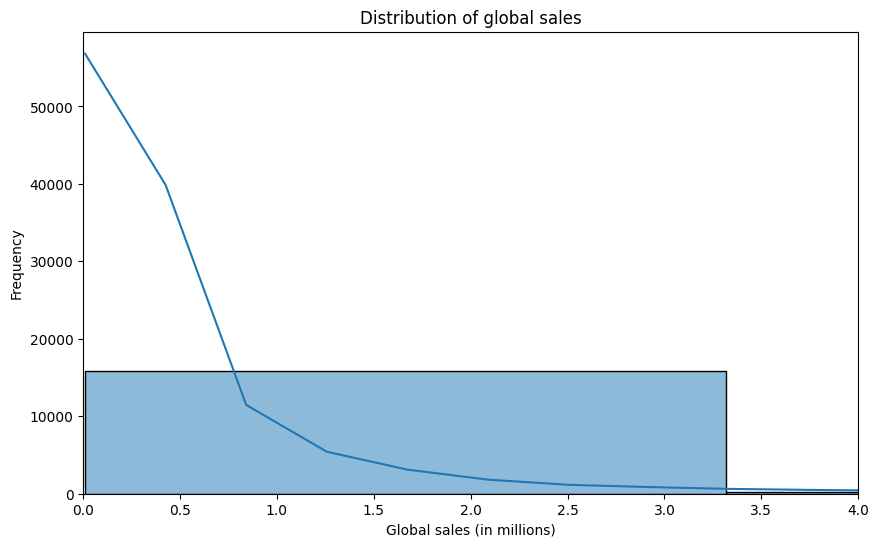

In [8]:
# Visualization 1: histogram of global sales
sns.histplot(df_clean['Global_Sales'], bins=25, kde=True)
plt.title('Distribution of global sales')
plt.xlabel('Global sales (in millions)')
plt.ylabel('Frequency')
plt.xlim(0, 4) # limiting x-axis to zoom in
plt.show()

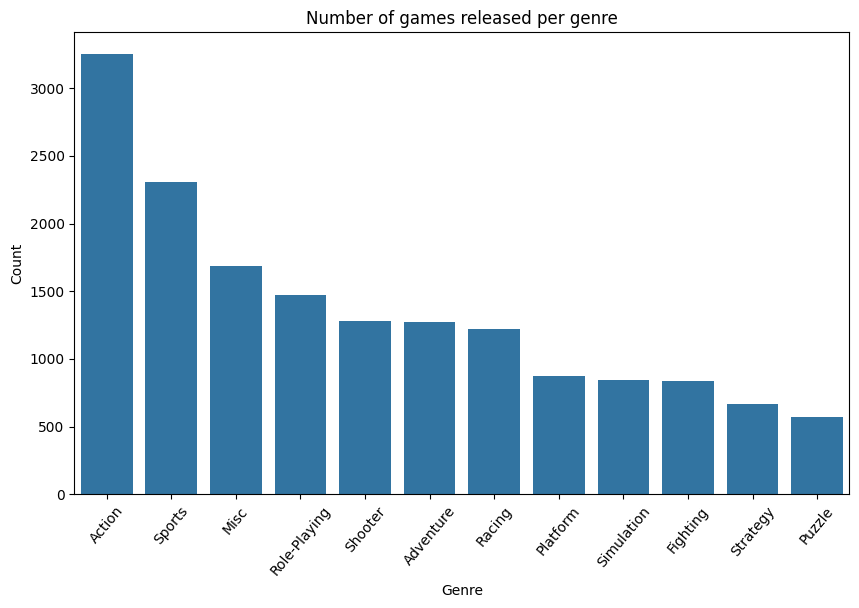

In [9]:
# Visualization 2: bar chart of counts by genre
sns.countplot(x='Genre', data=df_clean, order=df_clean['Genre'].value_counts().index)
plt.title('Number of games released per genre')
plt.ylabel('Count')
plt.xticks(rotation=50)
plt.show()

C:\Users\sydyk\AppData\Local\Temp\ipykernel_2928\3113151985.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Global_Sales', data=df_clean, palette='Set2')


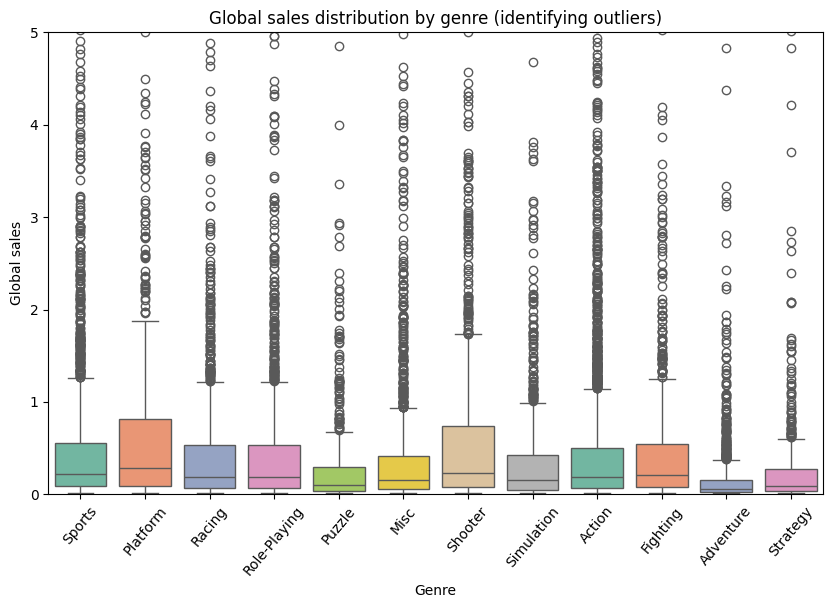

In [10]:
# Visualization 3: boxplot of sales by genre
sns.boxplot(x='Genre', y='Global_Sales', data=df_clean, palette='Set2')
plt.title('Global sales distribution by genre (identifying outliers)')
plt.ylim(0, 5)
plt.ylabel('Global sales')
plt.xticks(rotation=50)
plt.show()

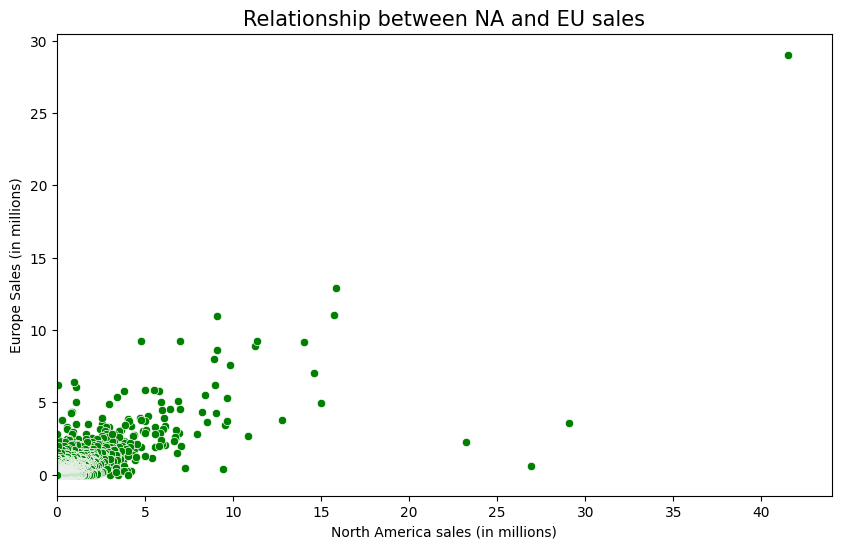

In [11]:
# Visualization 4: scatterplot. NA Sales versus EU Sales
sns.scatterplot(x='NA_Sales', y='EU_Sales', data=df_clean, color='green')
plt.title('Relationship between NA and EU sales', fontsize=15)
plt.xlabel('North America sales (in millions)')
plt.ylabel('Europe Sales (in millions)')
plt.xlim(0, 44)
plt.show()

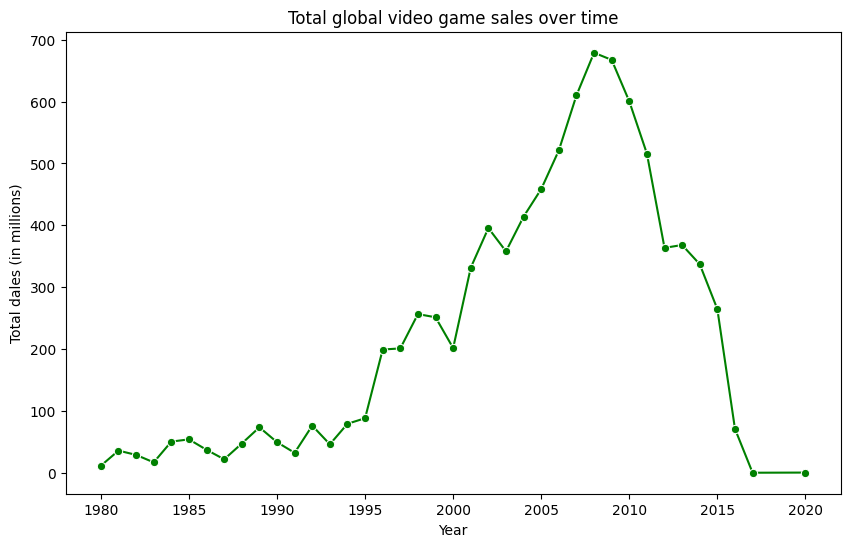

In [12]:
# Visualization 5: line сhart - total global sales over time
yearly_sales = df_clean.groupby('Year')['Global_Sales'].sum().reset_index()

sns.lineplot(x='Year', y='Global_Sales', data=yearly_sales, marker='o', color='green')
plt.title('Total global video game sales over time')
plt.xlabel('Year')
plt.ylabel('Total dales (in millions)')
plt.show()

## Relationship Analysis
Analyzing correlations between different regional markets

Correlation matrix:


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.768923,0.451283,0.634518,0.941269
EU_Sales,0.768923,1.000000,0.436379,0.726256,0.903264
JP_Sales,0.451283,0.436379,1.000000,0.290559,0.612774
Other_Sales,0.634518,0.726256,0.290559,1.000000,0.747964
Global_Sales,0.941269,0.903264,0.612774,0.747964,1.000000


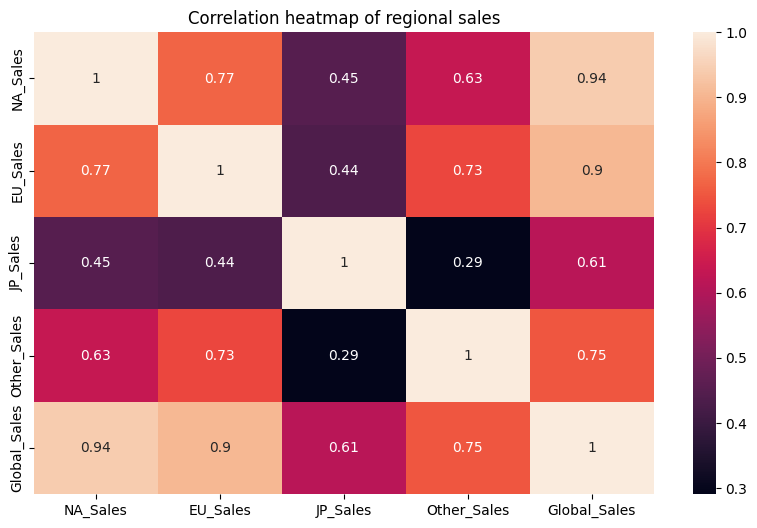

In [13]:
# 1. Correlation matrix
# For correlation we need only numerical columns, so
corr_matrix = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
corr_matrix = corr_matrix.corr()

print("Correlation matrix:")
display(corr_matrix)

print("")

sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation heatmap of regional sales')
plt.show()

### Interpretation of Relationships
*   **NA vs EU:** there is a strong positive correlation between NA and EU sales (0.77). Game successful in NA is likely successful in EU.
*   **NA vs JP:** the correlation is weaker (0.44). The JP market has distinct gaming preferences if we compare with NA

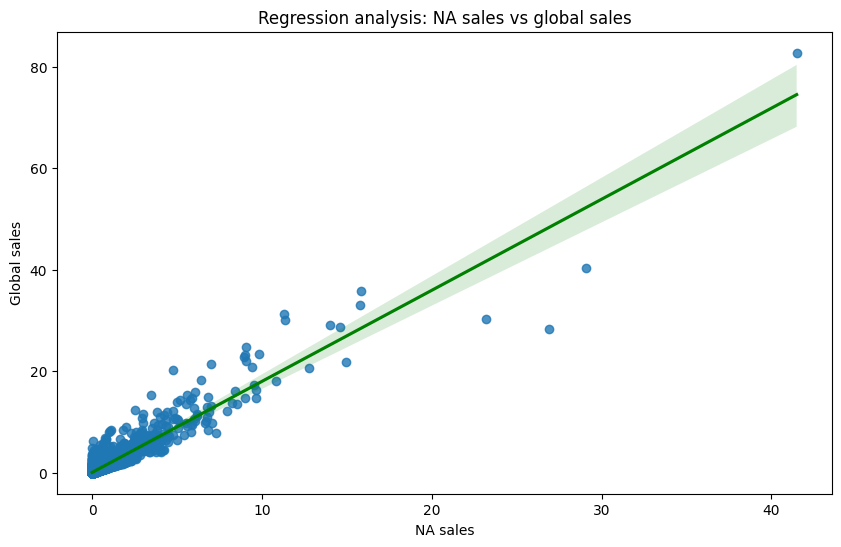

In [14]:
# 3. Scatterplot with regression line
# Exploring if NA Sales strongly predict global sales?
sns.regplot(x='NA_Sales', y='Global_Sales', data=df_clean, line_kws={'color':'green'})
plt.title('Regression analysis: NA sales vs global sales')
plt.ylabel("Global sales")
plt.xlabel("NA sales")
plt.show()

**The graph shows a strong positive correlation between NA sales and global sales, with the regression line indicating that higher NA sales predict higher global sales. Most games cluster at lower sales volumes, while a few outliers demonstrate are extremely high in both sales**

In [15]:
# Grouped analysis: correlation between NA and EU sales by genre
# We want to see if the relationship is stronger in some genres than others?

print("Correlation between NA and EU Sales by specific genres:")
to_check = ['Action', 'Sports','Role-Playing']

for genre in to_check:
    genre_data = df_clean[df_clean['Genre'] == genre]
    correlation = genre_data['NA_Sales'].corr(genre_data['EU_Sales'])
    print(f"{genre}: {correlation}")

Correlation between NA and EU Sales by specific genres:
Action: 0.8007330127790601
Sports: 0.8613327227113808
Role-Playing: 0.8757784591821668


From this we can see that in role-playing and sports games relationships stronger that in action games